In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#DISPLAY FORMATTING
pd.set_option('display.float_format', "{:,.3f}".format)

filename = "FC26.csv"
df = pd.read_csv(filename)
df = df [["long_name","age","height_cm","overall", "potential", "player_positions", "value_eur", "release_clause_eur", "club_name","club_position","league_name", "league_level",
          "preferred_foot","weak_foot","skill_moves","international_reputation","work_rate","body_type"]]

df_org = df.copy()

C:\Users\Salman\AppData\Local\Temp\ipykernel_24728\641613272.py:9: DtypeWarning: Columns (0: player_tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filename)


In [34]:
df.drop_duplicates(inplace=True)
print(df.isnull().sum())
#df.dropna(how = 'all' ,inplace=True)

print(df[df['work_rate'].isna()])

#empty club, position, league means free agent
df.drop(columns=["work_rate"], inplace = True) # drop as it is empty for all
#for empty RC, add value + 15% val


long_name                       0
age                             0
height_cm                       0
overall                         0
potential                       0
player_positions                0
value_eur                       0
release_clause_eur           1434
club_name                      89
club_position                  89
league_name                    89
league_level                   89
preferred_foot                  0
weak_foot                       0
skill_moves                     0
international_reputation        0
work_rate                   18405
body_type                       0
dtype: int64
                                long_name  age  height_cm  overall  potential  \
0          Jude Victor William Bellingham   22        186       90         94   
1      Federico Santiago Valverde Dipetta   26        182       89         90   
2                   Joshua Walter Kimmich   30        177       89         89   
3            Achraf Hakimi Mouhأشرف حكيمي   26     

In [35]:
print(df[df.release_clause_eur.isna()].index)
for i in df[df.release_clause_eur.isnull()].index:
    df.loc[i, "release_clause_eur"] = df.loc[i, "value_eur"] *1.25

print(df.isnull().sum())
 


Index([   16,    55,    95,   111,   159,   171,   181,   221,   225,   245,
       ...
       17985, 17988, 18010, 18011, 18086, 18107, 18127, 18137, 18231, 18328],
      dtype='int64', length=1434)
long_name                    0
age                          0
height_cm                    0
overall                      0
potential                    0
player_positions             0
value_eur                    0
release_clause_eur           0
club_name                   89
club_position               89
league_name                 89
league_level                89
preferred_foot               0
weak_foot                    0
skill_moves                  0
international_reputation     0
body_type                    0
dtype: int64


In [36]:
#now fixing positions part, taking only 1 preferred position
c = 'player_positions' #variable to hold column name
print(df[c].head())
df[c] = df[c].str.split(",").str[0].str.strip()
print(df[c].head())


0        CAM, CM
1    CM, CDM, RB
2    CDM, RB, CM
3         RB, RM
4             CM
Name: player_positions, dtype: str
0    CAM
1     CM
2    CDM
3     RB
4     CM
Name: player_positions, dtype: object


In [37]:
print(df.info())
#now encode non numeric columns
#nonNumeric = ["long_name", "player_positions","preferred_foot","body_type"]
#DROP NAME
df.drop(columns = "long_name", inplace=True)
nonNumeric = df.select_dtypes(exclude = ["number"])

<class 'pandas.DataFrame'>
RangeIndex: 18405 entries, 0 to 18404
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   long_name                 18405 non-null  str    
 1   age                       18405 non-null  int64  
 2   height_cm                 18405 non-null  int64  
 3   overall                   18405 non-null  int64  
 4   potential                 18405 non-null  int64  
 5   player_positions          18405 non-null  object 
 6   value_eur                 18405 non-null  int64  
 7   release_clause_eur        18405 non-null  float64
 8   club_name                 18316 non-null  str    
 9   club_position             18316 non-null  str    
 10  league_name               18316 non-null  str    
 11  league_level              18316 non-null  float64
 12  preferred_foot            18405 non-null  str    
 13  weak_foot                 18405 non-null  int64  
 14  skill_moves      

In [38]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
for c in nonNumeric:
    df[c] = LabelEncoder().fit_transform(df[c])

#no column really requires scaling, lets still go for age
scaler = StandardScaler()
columns_to_scale = ['age']
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

In [39]:
print(df.head())


     age  height_cm  overall  potential  player_positions  value_eur  \
0 -0.675        186       90         94                 0  174500000   
1  0.163        182       89         90                 3  120500000   
2  1.001        177       89         89                 2   86000000   
3  0.163        181       89         90                 8  111000000   
4  0.582        175       87         87                 3   79500000   

   release_clause_eur  club_name  club_position  league_name  league_level  \
0     370,800,000.000        485              0           15         1.000   
1     256,100,000.000        485             17           15         1.000   
2     141,900,000.000        216             17            5         1.000   
3     213,700,000.000        442             14           22         1.000   
4     131,199,999.000        330             16           35         1.000   

   preferred_foot  weak_foot  skill_moves  international_reputation  body_type  
0               1

Text(0.5, 1.0, 'Before Outlier Removal - league_level')

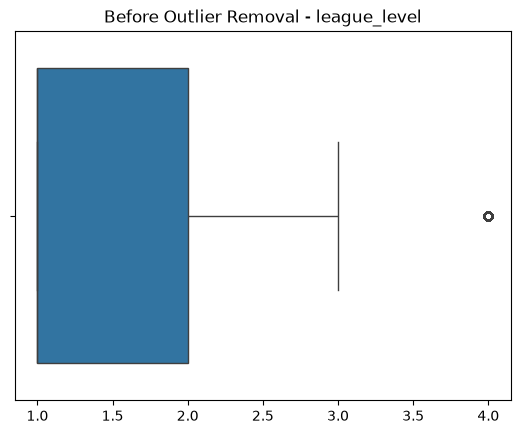

In [40]:
#in our dataset, outliers should not be removed as they are main points, so I am not removing for most columns, removing only for league_level
df_new = df.copy()
c = "league_level"
sns.boxplot(x = df_new[c])
plt.xlabel("")
plt.title(f"Before Outlier Removal - {c}")

In [41]:
Q1 = df_new[c].quantile(0.25)
Q3 = df_new[c].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
higher_bound = Q3 + 1.5*IQR

df_new = df_new[(df_new[c] >= lower_bound) & (df_new[c] <=higher_bound)]


Text(0.5, 1.0, 'After Outlier Removal - league_level')

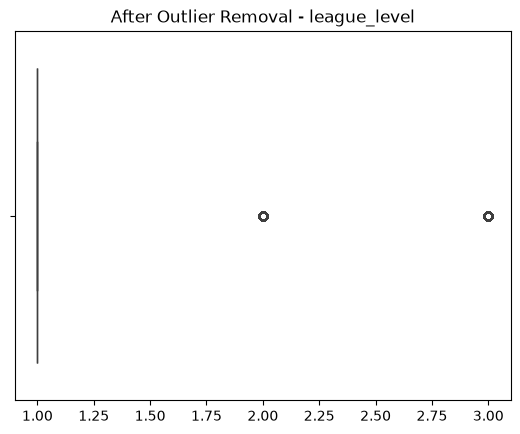

In [42]:
sns.boxplot(x = df_new[c])
plt.xlabel("")
plt.title(f"After Outlier Removal - {c}")

In [43]:
#oversampling,undersampling and combination
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
X = df_new.drop(columns = ["value_eur"])
y = df_new["value_eur"] #target column

##########below portion will not work as it is a continiuous variable
print("Original Value Counts: ",y.value_counts())
#balanced = SMOTETomek(random_state=42)
#X_resampled, y_resampled = balanced.fit_resample(X,y)
#print("Resampled Datasize: ", y_resampled.value_counts())



Original Value Counts:  value_eur
1200000     599
1100000     560
1600000     508
1300000     502
1000000     486
           ... 
84000000      1
83000000      1
70000000      1
61000000      1
97000000      1
Name: count, Length: 248, dtype: int64


In [44]:
###Phase 2
###Moved Heatmap (Co-relation analysis from Phase 1 to Phase 2 too), same goes for Feature Transformation

<Axes: xlabel='value_eur', ylabel='Count'>

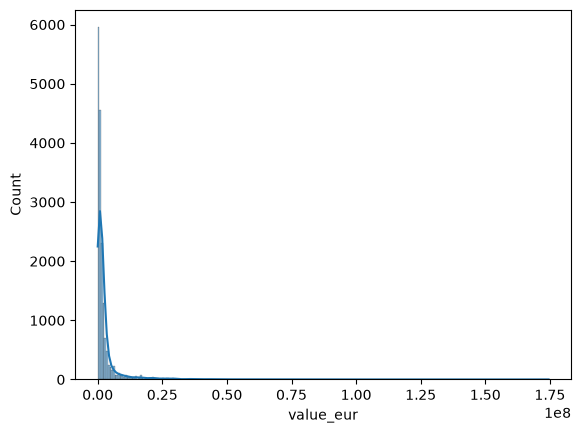

In [45]:
##FEATURE TRANSFORMATION
import numpy as np
sns.histplot(df_new['value_eur'], kde=True)


<Axes: xlabel='log_value', ylabel='Count'>

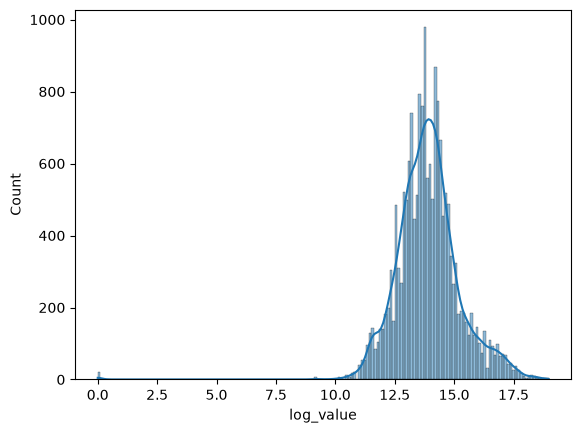

In [46]:
#my distribution looks like a gamma distribution 
#as my target column is not 0/1, I cannot simply apply undersampling, oversampling or combination.
#i am applying log trasnform beacuse most of the players have low market values with very few having huge values
#it will lessen the influence of extremely valuable players, and create a more stable relationship between features and target values.
#so the model may not spend too much effort fitting a few elite players and ignore ordinary players.


df_new = pd.concat([X,y], axis = 1)
df_new['log_value'] = np.log1p(df_new['value_eur'])
df_new['log_rc'] = np.log1p(df_new['release_clause_eur'])
df_new.to_csv("Updated.csv", index = False)
sns.histplot(df_new['log_value'], kde=True)

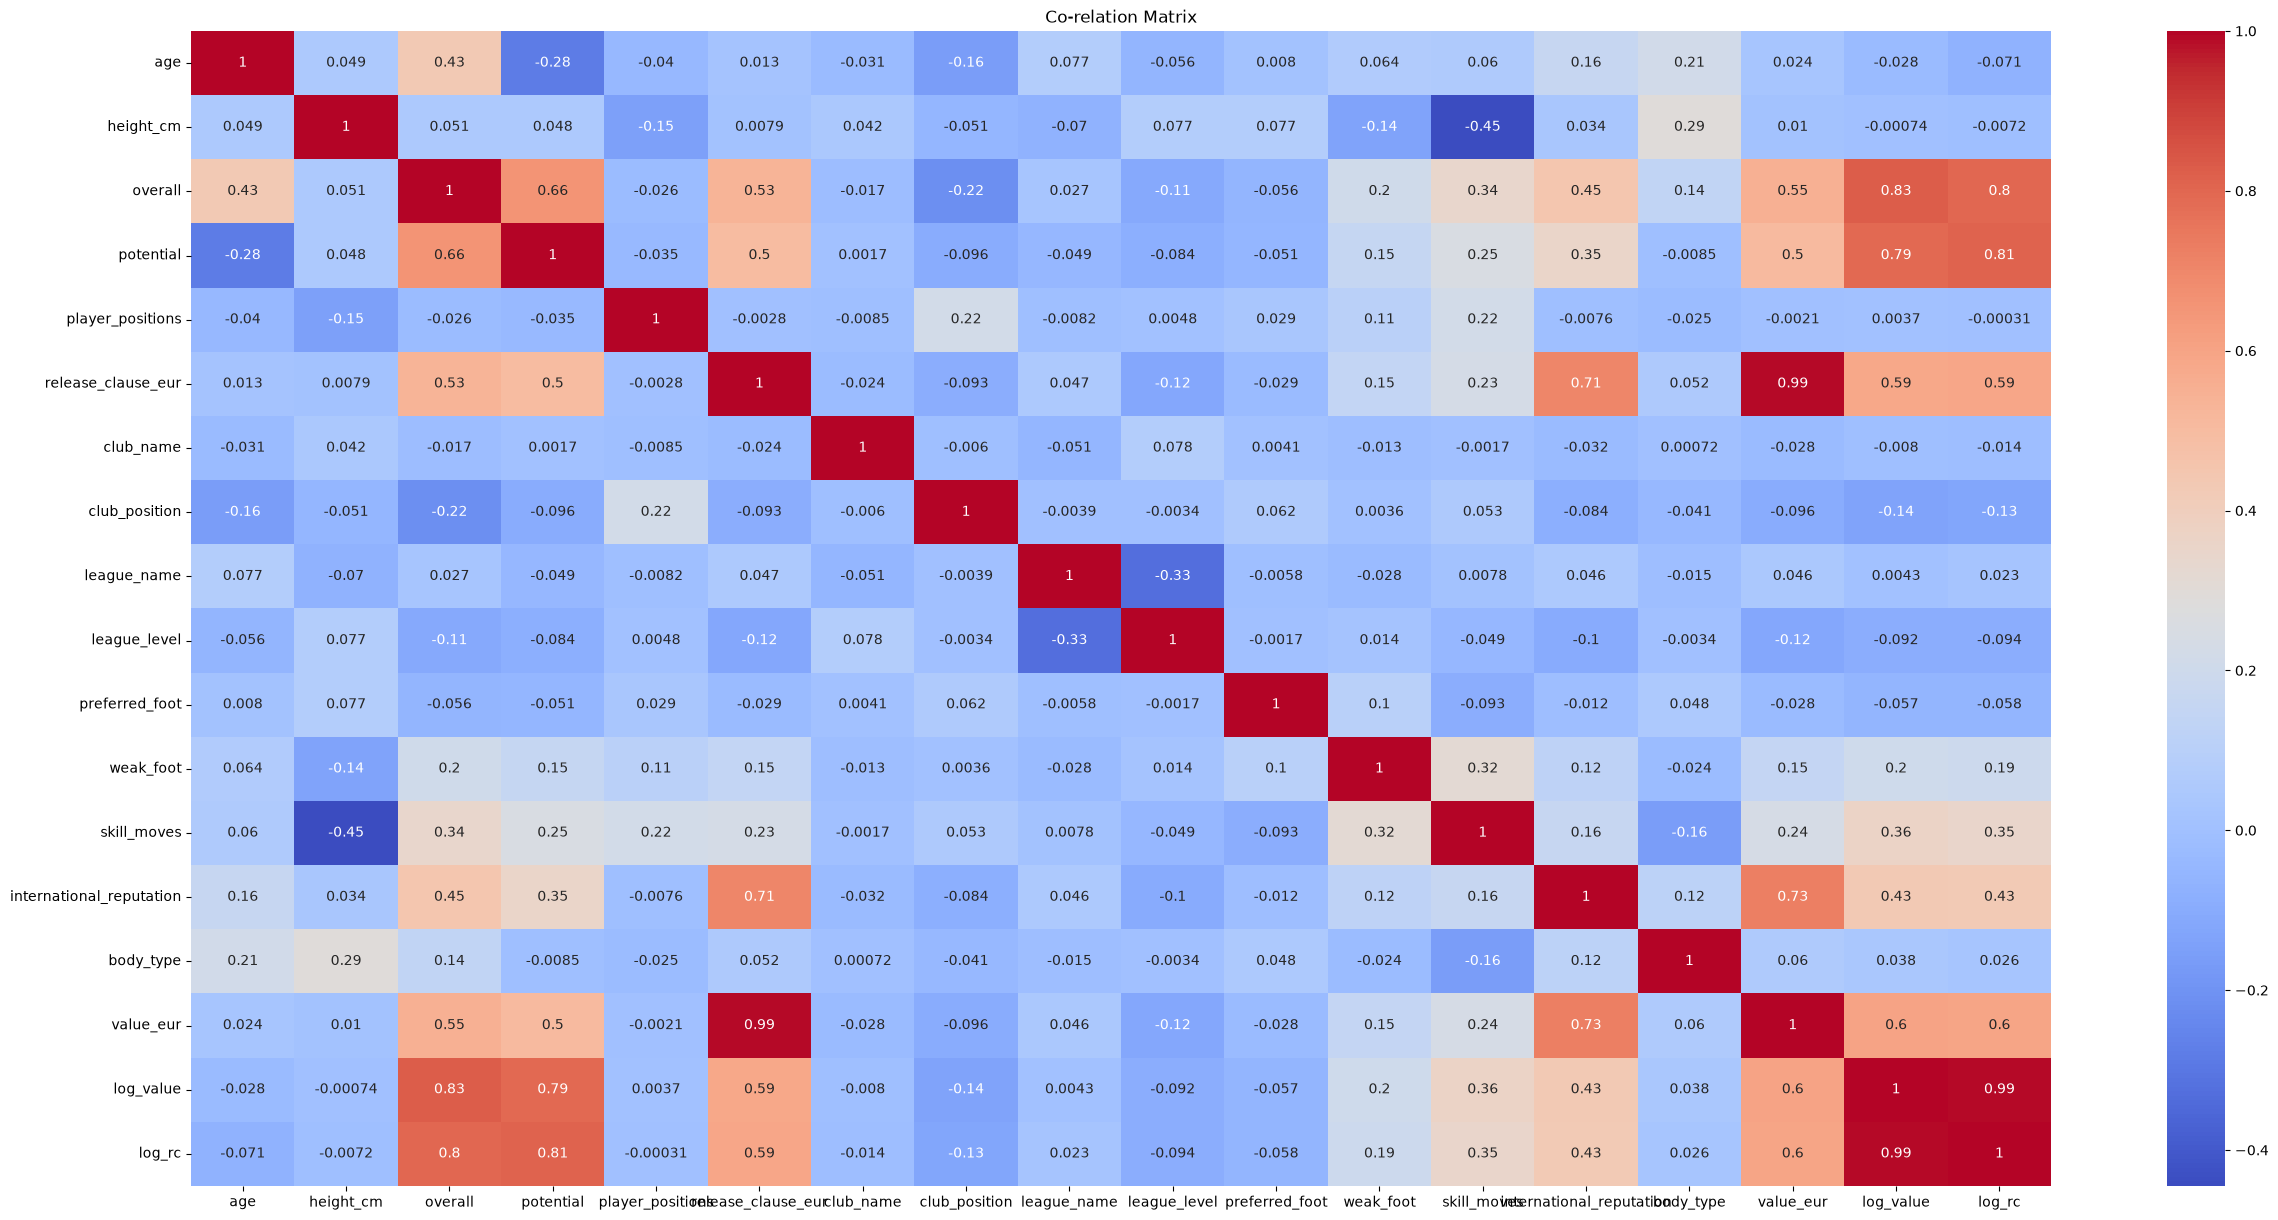

In [47]:
#FEATURE SELECTION
#1.CO-RELATION ANALYSIS

import seaborn as sns
import matplotlib.pyplot as plt

matrix = df_new.corr()
plt.figure(figsize=(30,15))
sns.heatmap(matrix, annot = True, cmap = 'coolwarm')
plt.title("Co-relation Matrix")
plt.xticks(rotation = 360)
plt.show()

In [48]:
#altho overall and potential do give similiar info and have similar trend, but I cannot drop them because they still give different information


unnecessary_cols = ["player_positions","club_name","height_cm","preferred_foot", "value_eur", "release_clause_eur"]
df_new = df_new.drop(columns = unnecessary_cols)




In [49]:
#NO Date Time Feature Extraction as I don't have any temporal columns
#NO Text columns contaning paragraphs so no process like TF-IDF done

In [50]:
#2.Variance Threshold
#works on numeric cols only, so lets separate
X = df_new.drop(columns = ["log_value"])
y = df_new["log_value"]

numeric_X = X.select_dtypes(exclude=["str"])
print("Numeric Columns are: ", numeric_X.columns)
print("Currently, the variances are: \n",numeric_X.var())


Numeric Columns are:  Index(['age', 'overall', 'potential', 'club_position', 'league_name',
       'league_level', 'weak_foot', 'skill_moves', 'international_reputation',
       'body_type', 'log_rc'],
      dtype='str')
Currently, the variances are: 
 age                          0.997
overall                     48.832
potential                   40.488
club_position               45.016
league_name                143.005
league_level                 0.348
weak_foot                    0.445
skill_moves                  0.594
international_reputation     0.155
body_type                    3.385
log_rc                       1.953
dtype: float64


In [51]:
#as international repo, preferred foot variate quite less but stil not around 0.01 or very low, so right now we cannot make a
#rigid decision to directly drop them, maybe they have some influence in predicting market values, we'll see with our feature selection techniques
#applying Variance Threshold, to automatically remove columns with var <0.01, THIS WOULD REMOVE NOTHING OF COURSE FOR NOW
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(numeric_X)

selected_columns = numeric_X.columns[selector.get_support()]
removed_columns = numeric_X.columns[~selector.get_support()]

print("Columns selected by Variance Threshold: ", selected_columns)
print("Columns removed by Variance Threshold: ", removed_columns)

Columns selected by Variance Threshold:  Index(['age', 'overall', 'potential', 'club_position', 'league_name',
       'league_level', 'weak_foot', 'skill_moves', 'international_reputation',
       'body_type', 'log_rc'],
      dtype='str')
Columns removed by Variance Threshold:  Index([], dtype='str')


In [52]:
#3.Mutual Info
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X,y,random_state = 42)
mi_dframe = pd.DataFrame({"Feature":X.columns, "Scores":mi_scores})

mi_dframe = mi_dframe.sort_values(by= "Scores", ascending = False)
print("Mutual Inforamtion scores are: \n",mi_dframe)

#REMOVE COLUMNS IN NEXT STEP - SELECT KBEST

Mutual Inforamtion scores are: 
                      Feature  Scores
10                    log_rc   2.694
1                    overall   1.312
2                  potential   1.002
4                league_name   0.306
0                        age   0.236
8   international_reputation   0.123
7                skill_moves   0.108
3              club_position   0.093
5               league_level   0.060
9                  body_type   0.022
6                  weak_foot   0.020


In [53]:
#4.SelectKBest
#we have chi2, f_classif, f_regession, mutual_regression

#both regression ones can be used but f_regression is for more linear relatinoshisps,
#mutual_regression can help us better I think because it can detect no linear rship too
#  because age 18 player has less value, a mature 25 player has more, then 30 yo player has less value
#so it is not a straitht line realtionsihp


#REMEMBER X must be encoded as categorical variables should be encoded
target = ["log_value"]
X = df_new[selected_columns]
y = df_new[target]

from sklearn.feature_selection import SelectKBest

selector = SelectKBest (score_func=mutual_info_regression, k = 'all')
selector.fit(X,y)

#FIRST display, then remove in next cell
scores = pd.DataFrame({'Feature': X.columns,'Score': selector.scores_})
scores = scores.sort_values(by='Score',ascending=False)
print(scores)


C:\Users\Salman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


                     Feature  Score
10                    log_rc  2.708
1                    overall  1.316
2                  potential  1.004
4                league_name  0.304
0                        age  0.247
7                skill_moves  0.114
8   international_reputation  0.112
3              club_position  0.084
5               league_level  0.059
6                  weak_foot  0.025
9                  body_type  0.011


In [54]:
#now select till age, k = 5
kVal = 5
selector = SelectKBest(score_func=mutual_info_regression, k = kVal)
X_selected = selector.fit_transform(X,y)

selected_columns = X.columns[selector.get_support()]
removed_columns = X.columns[~selector.get_support()]

print(f"Columns selected by K-best for k={kVal}", selected_columns)
print(f"Columns removed by K-best", removed_columns)


C:\Users\Salman\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Columns selected by K-best for k=5 Index(['age', 'overall', 'potential', 'league_name', 'log_rc'], dtype='str')
Columns removed by K-best Index(['club_position', 'league_level', 'weak_foot', 'skill_moves',
       'international_reputation', 'body_type'],
      dtype='str')


# Exploratory Data Analysis (EDA) & Visualizations
**Histogram**

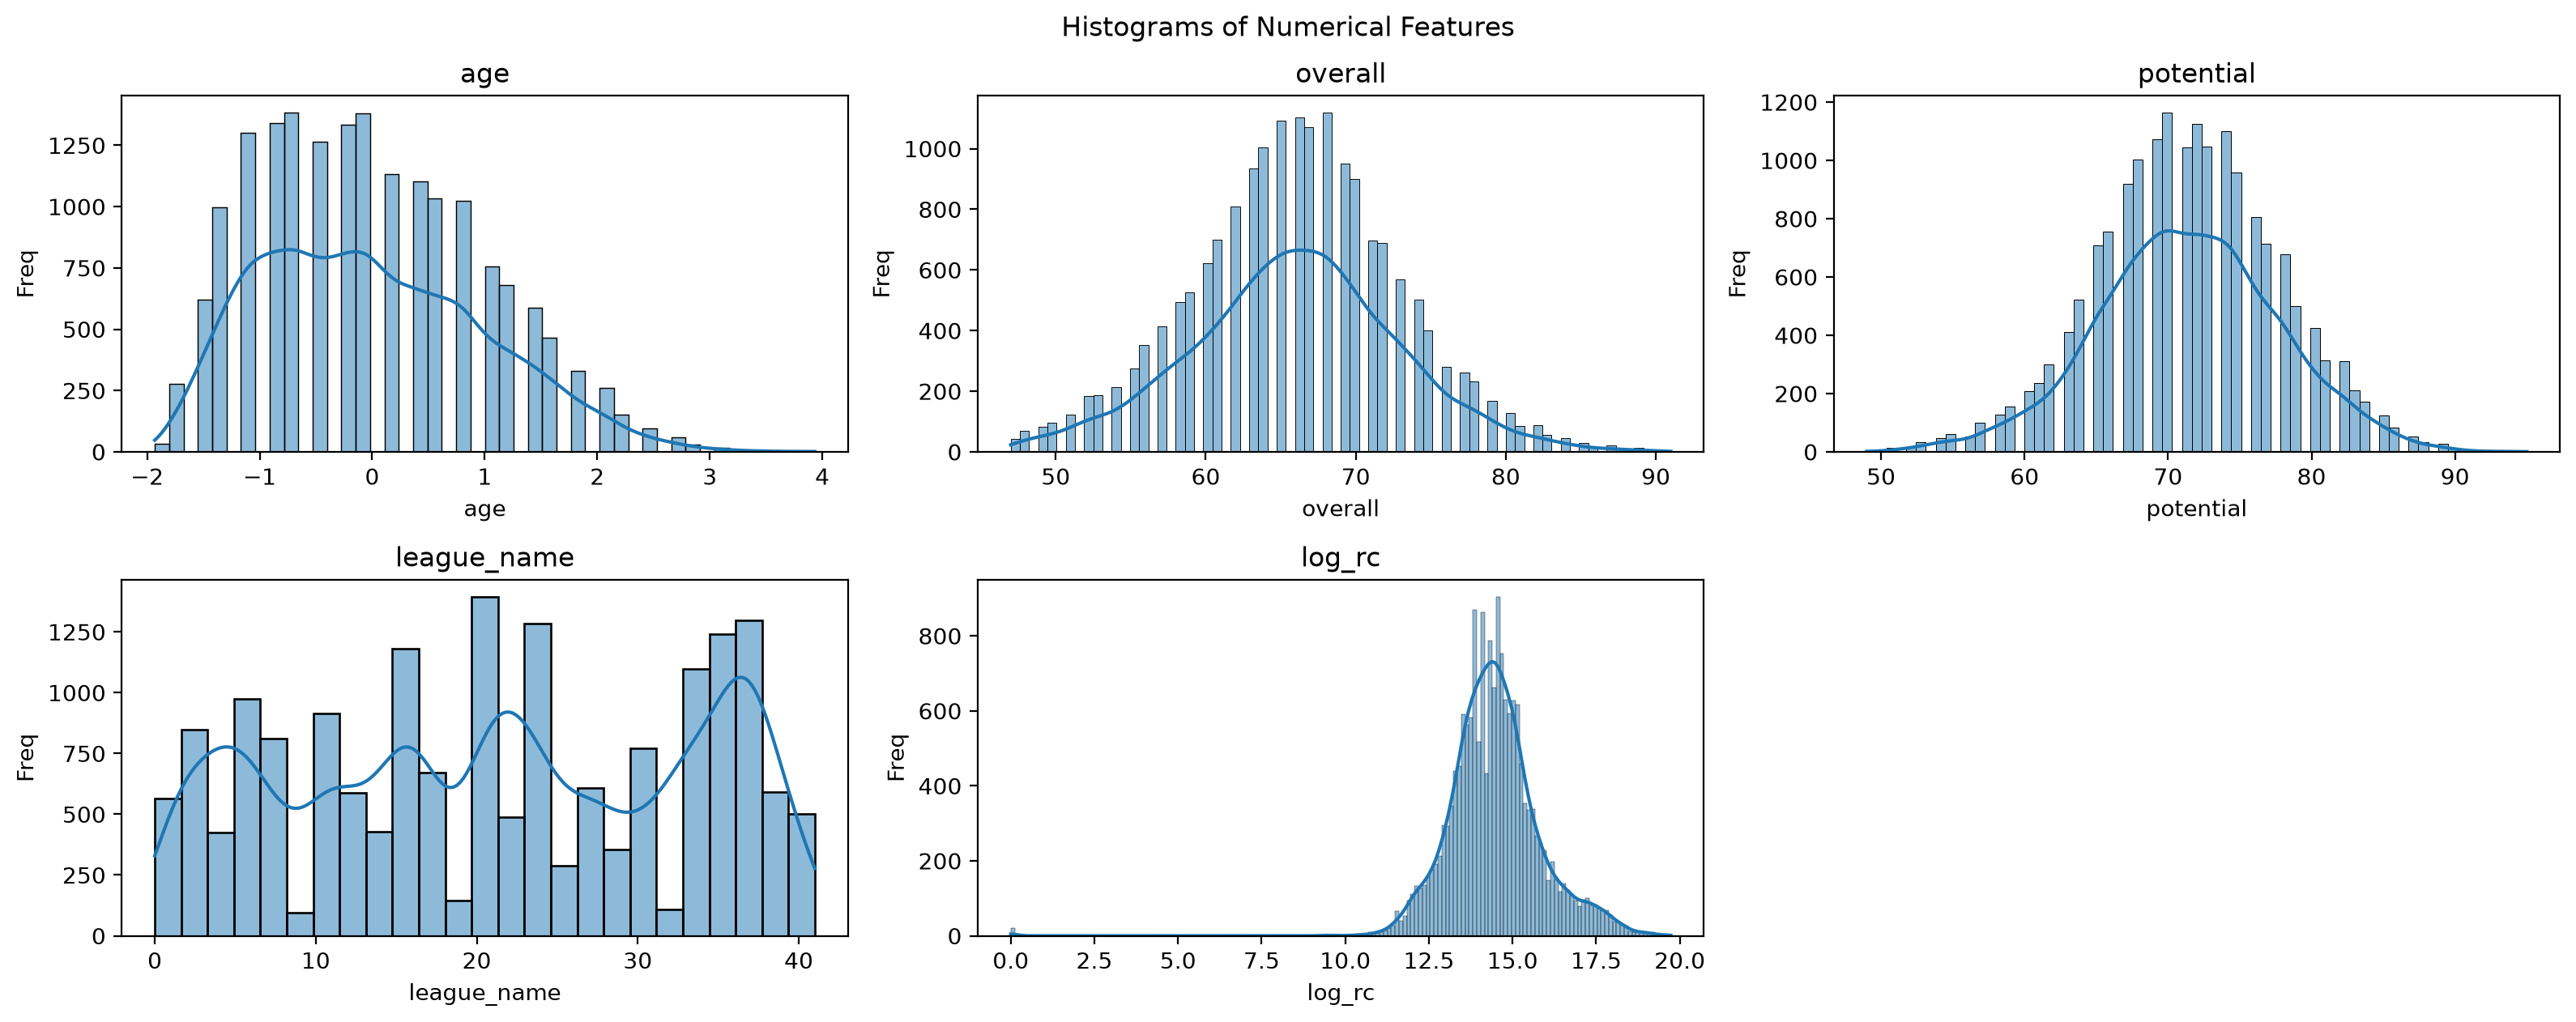

In [55]:
#charting
import math
df_final = pd.concat([df_new[selected_columns], y], axis = 1)

#altho all are numeric now, but lets do it anyway as a fallback
numeric_cols = df_final.select_dtypes(exclude=["str"])
numeric_cols.drop(columns = ["log_value"], inplace= True)
N = numeric_cols.shape[1] #gives no of cols

plt.figure(figsize=(16,9), dpi =200)

nr = math.ceil(N/2)
nc = math.ceil(N/2)
j = 1
for cols in numeric_cols:
    plt.subplot(nr,nc,j)
    j+=1
    sns.histplot(df_final[cols], kde = True)
    plt.xlabel(cols)
    plt.ylabel("Freq")
    plt.title(f"{cols}")


plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()


***Interpretation***
    League_name has a lot of fluctutaion as it is categorical
    Age is right skewed, others are approximately normal distributed

**Count Plots**


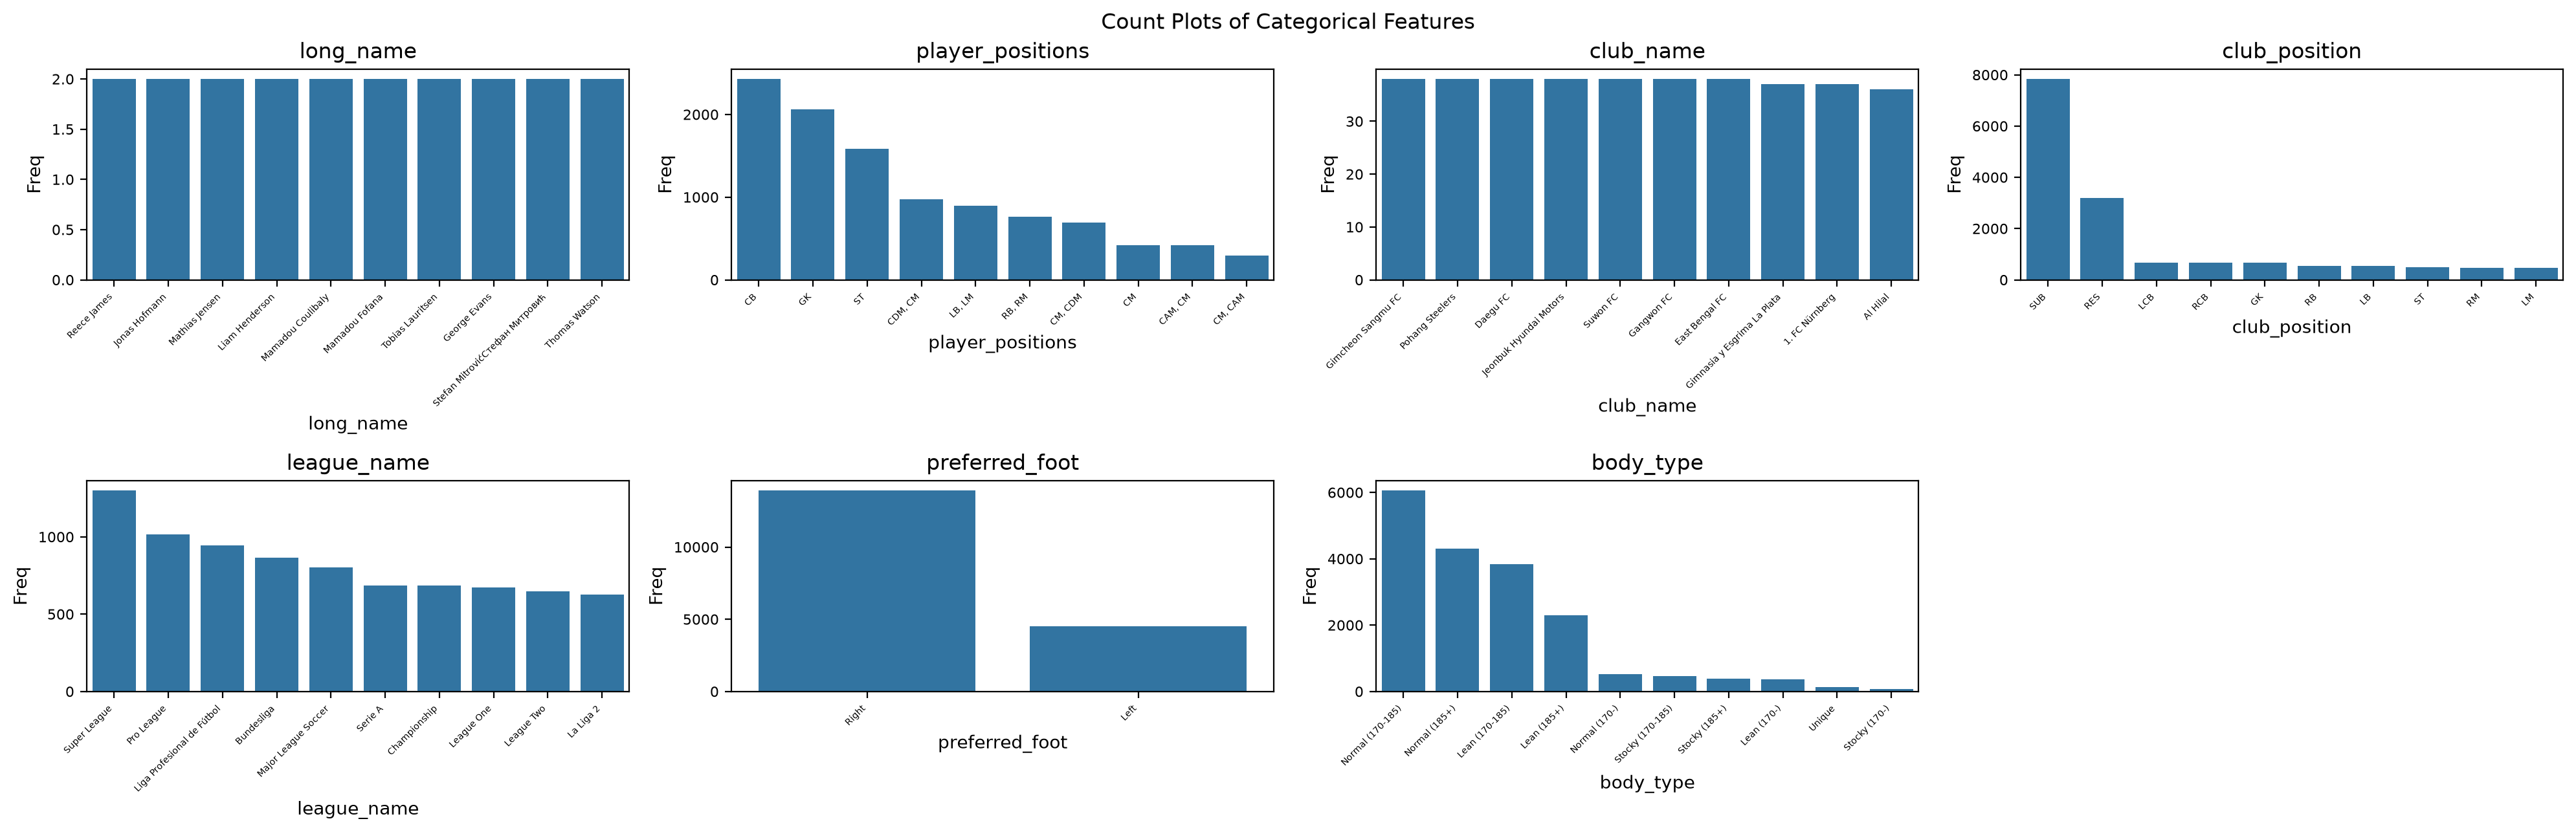

In [56]:

#as count plots are for categorial data, Ill use original dataset
categorical_cols = df_org.select_dtypes(include = ["str"])
N = categorical_cols.shape[1] #gives no of cols


nr = math.ceil(N/2)
nc = math.ceil(N/2)

plt.figure(figsize=(20,12), dpi =200)

j = 1
for cols in categorical_cols:
    plt.subplot(nr,nc,j)
    j+=1
    sns.countplot(data = df_org, x = cols, order = df_org[cols].value_counts().head(10).index)
    plt.xlabel(cols)
    plt.ylabel("Freq")
    plt.title(f"{cols}")
    plt.xticks(rotation = 45, ha ='right', fontsize =5)
    plt.yticks(fontsize=8)


plt.suptitle("Count Plots of Categorical Features")
plt.tight_layout()
plt.show()

***Interpretation***

There are some players who have same names
Most players are Center Backs
Most data is for Subsititue players
Most of the players prefer right foot
Most players have normal body type
Most players are from super league

**Boxplot for Outliers**


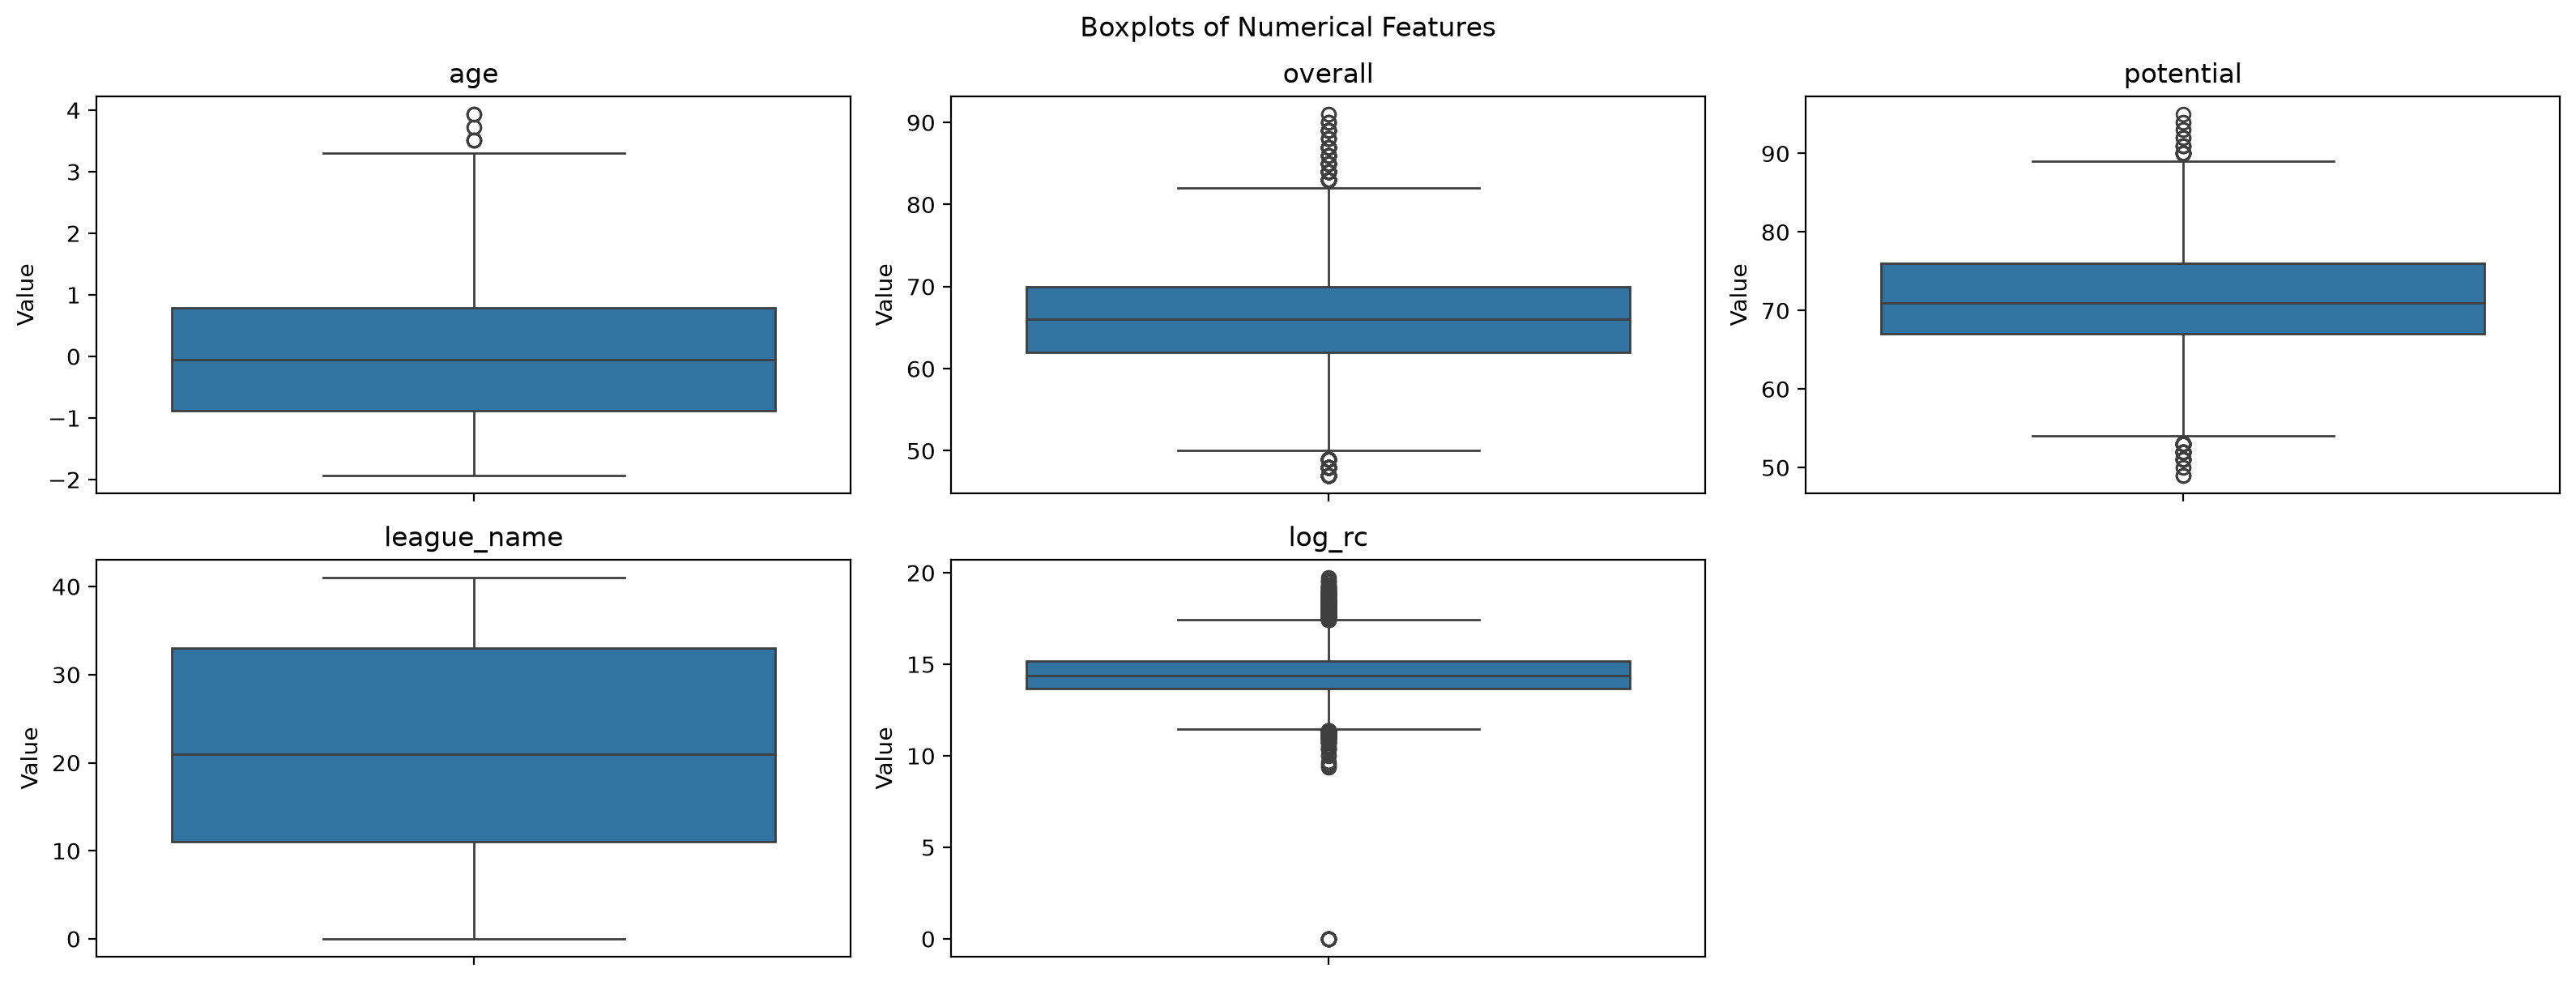

In [57]:

#altho all are numeric now, but lets do it anyway as a fallback
N = numeric_cols.shape[1] #gives no of cols

plt.figure(figsize=(16,9), dpi =200)

nr = math.ceil(N/2)
nc = math.ceil(N/2)
j = 1
for cols in numeric_cols:
    plt.subplot(nr,nc,j)
    j+=1
    sns.boxplot(df_final[cols])
    #plt.xlabel(cols)
    plt.ylabel("Value")
    plt.title(f"{cols}")


plt.suptitle("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()


***Interpretation***
There are some outliers in many columns because of elite players (and some very low rated players) of course we cannot remove them as they are the main feature of our data set

**Co-relation Heatmap**
already done above in corelation analysis, but lets do it anyway again

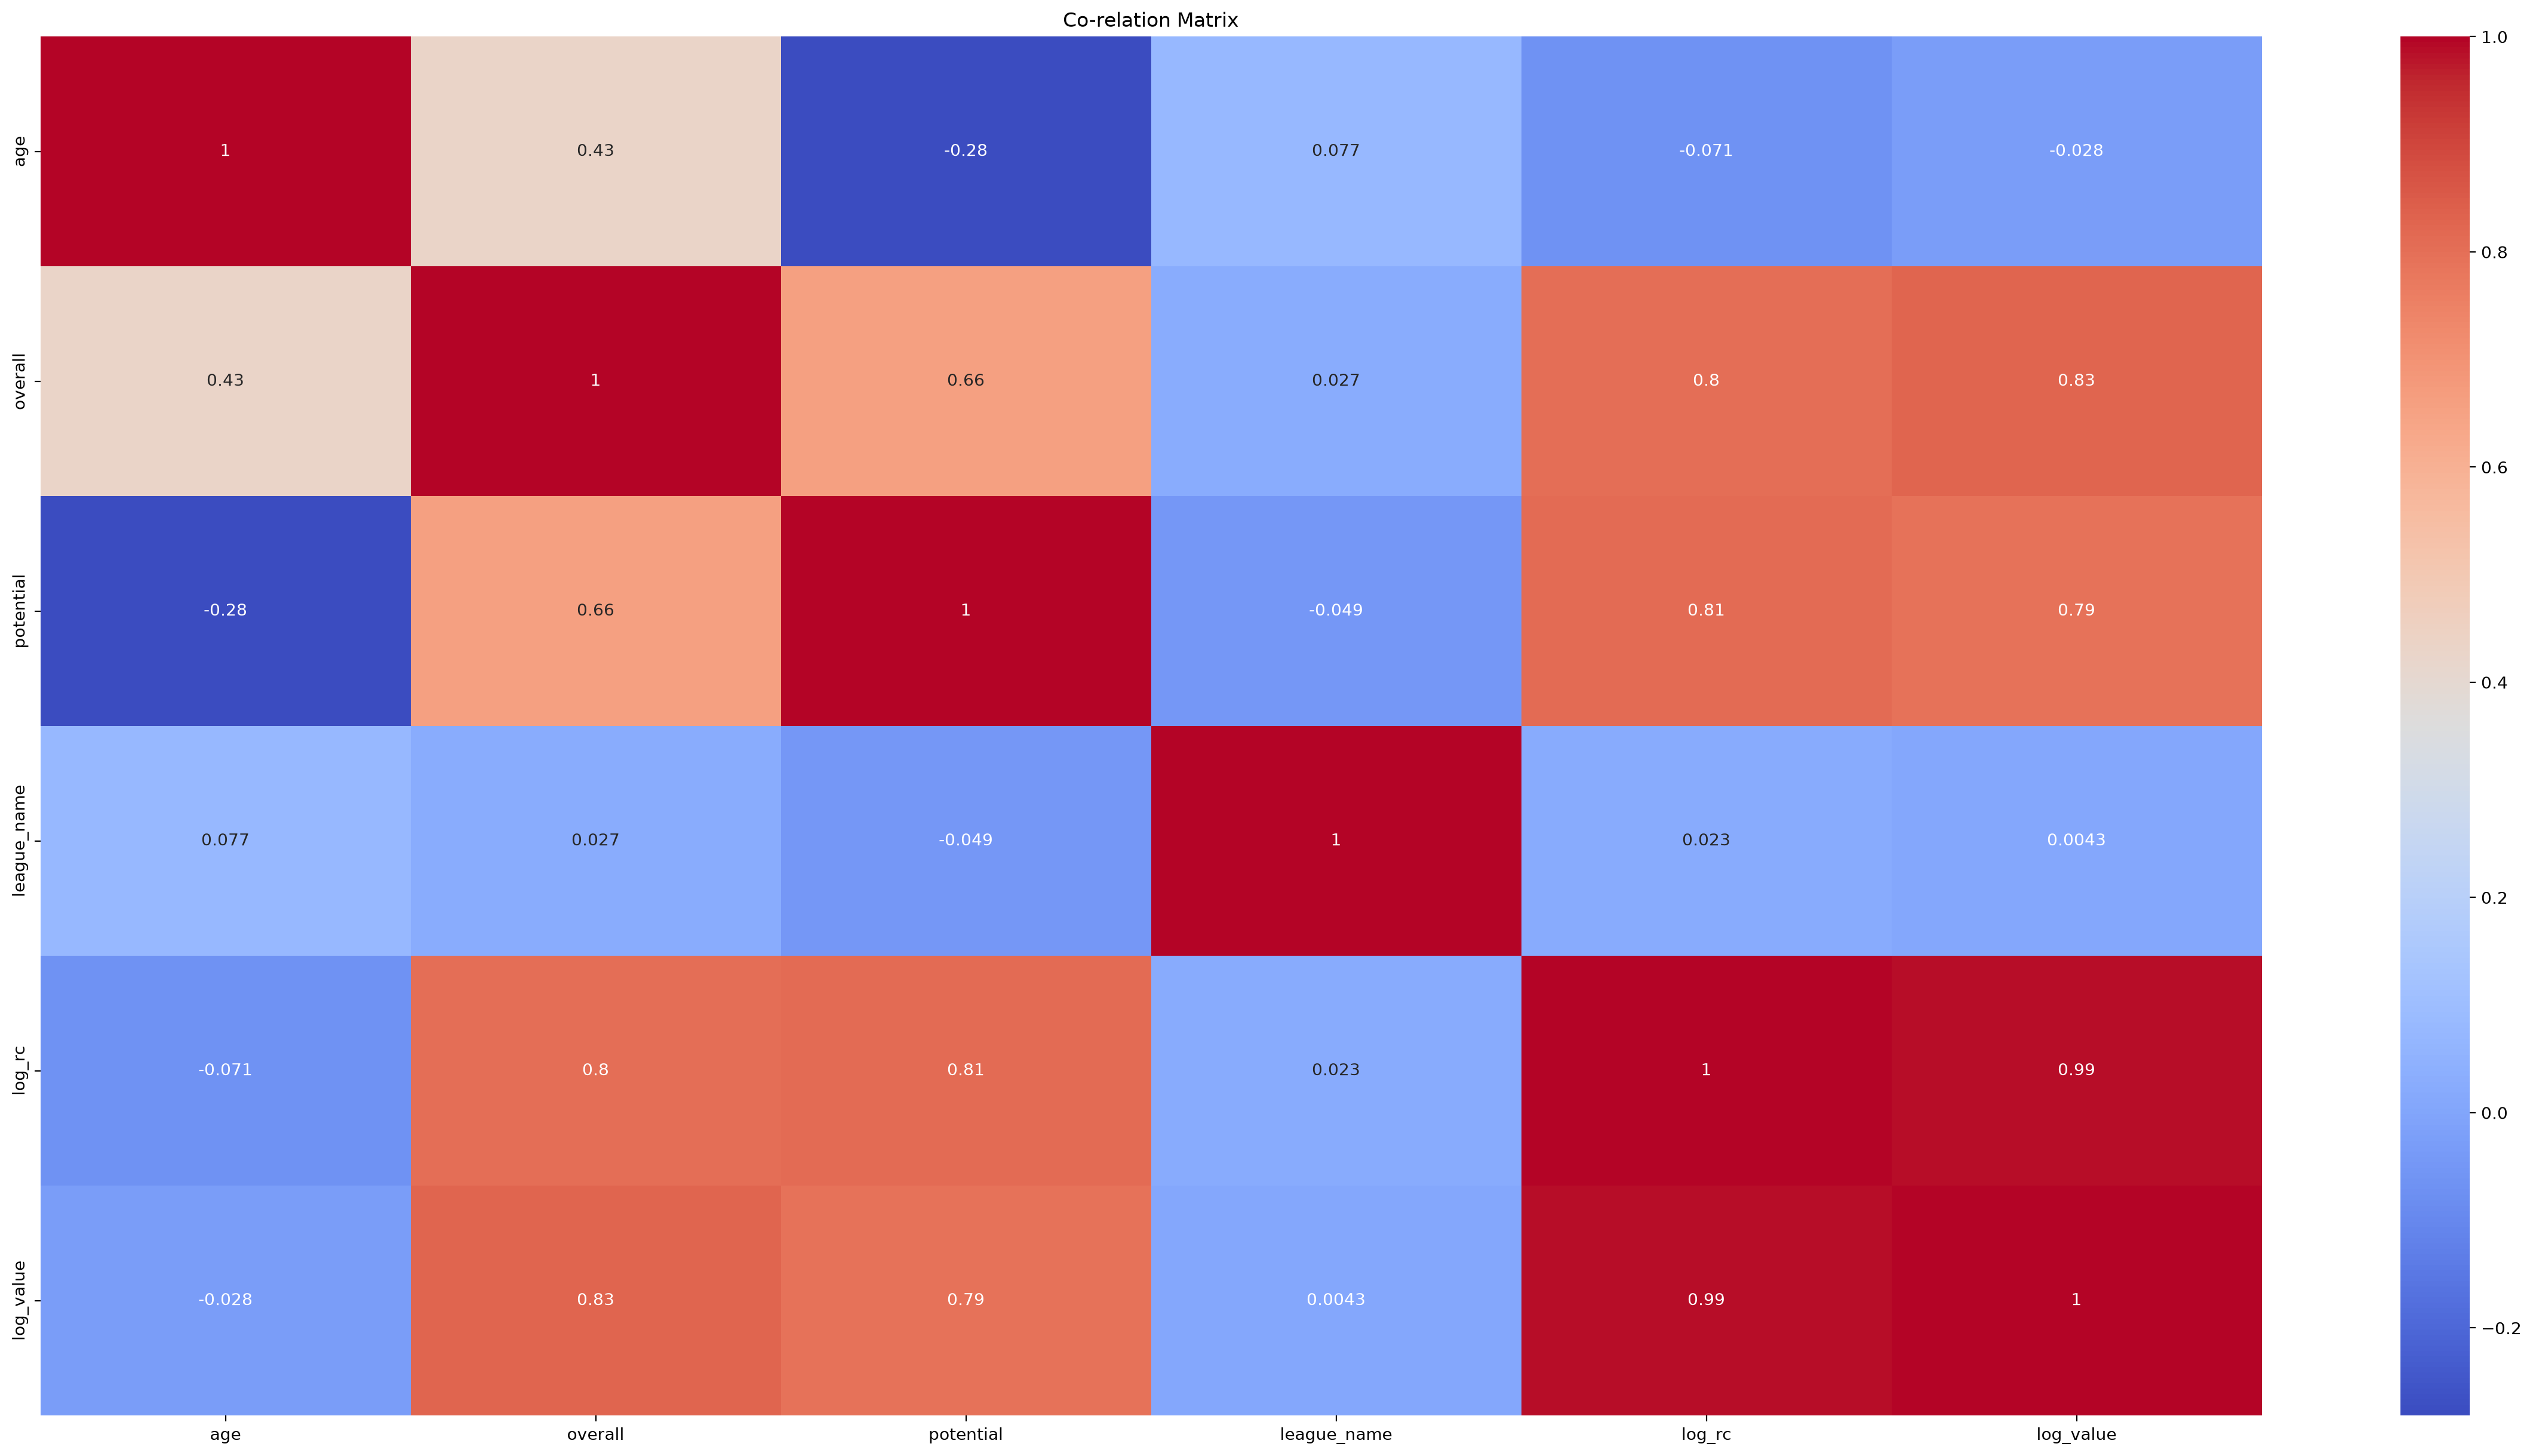

In [58]:
corr_matrix = df_final.corr()
plt.figure(figsize=(30,15), dpi = 200)
sns.heatmap(corr_matrix, annot =True,cmap = 'coolwarm')
plt.title("Co-relation Matrix")
plt.xticks(rotation = 360)
plt.show()

***Interpretation***
Naturally log_rc and log_value have very strong corelation
Overall and potentail also have corelation with target log_value

#here Leaguename shows no coorealtion, so I am going to drop it, but keeping age although its very low anyway

In [59]:

df_final.drop(columns = ["league_name"])

,age,overall,potential,log_rc,log_value
0,-0.675,90,94,19.731,18.977
1,0.163,89,90,19.361,18.607
2,1.001,89,89,18.771,18.270
3,0.163,89,90,19.180,18.525
4,0.582,87,87,18.692,18.191
...,...,...,...,...,...
18400,-0.885,48,54,11.374,11.002
18401,-0.466,49,56,11.849,11.290
18402,-0.885,48,59,11.783,11.408
18403,-0.885,51,61,12.049,11.608


**Pair Plot**

<Figure size 3200x1800 with 0 Axes>

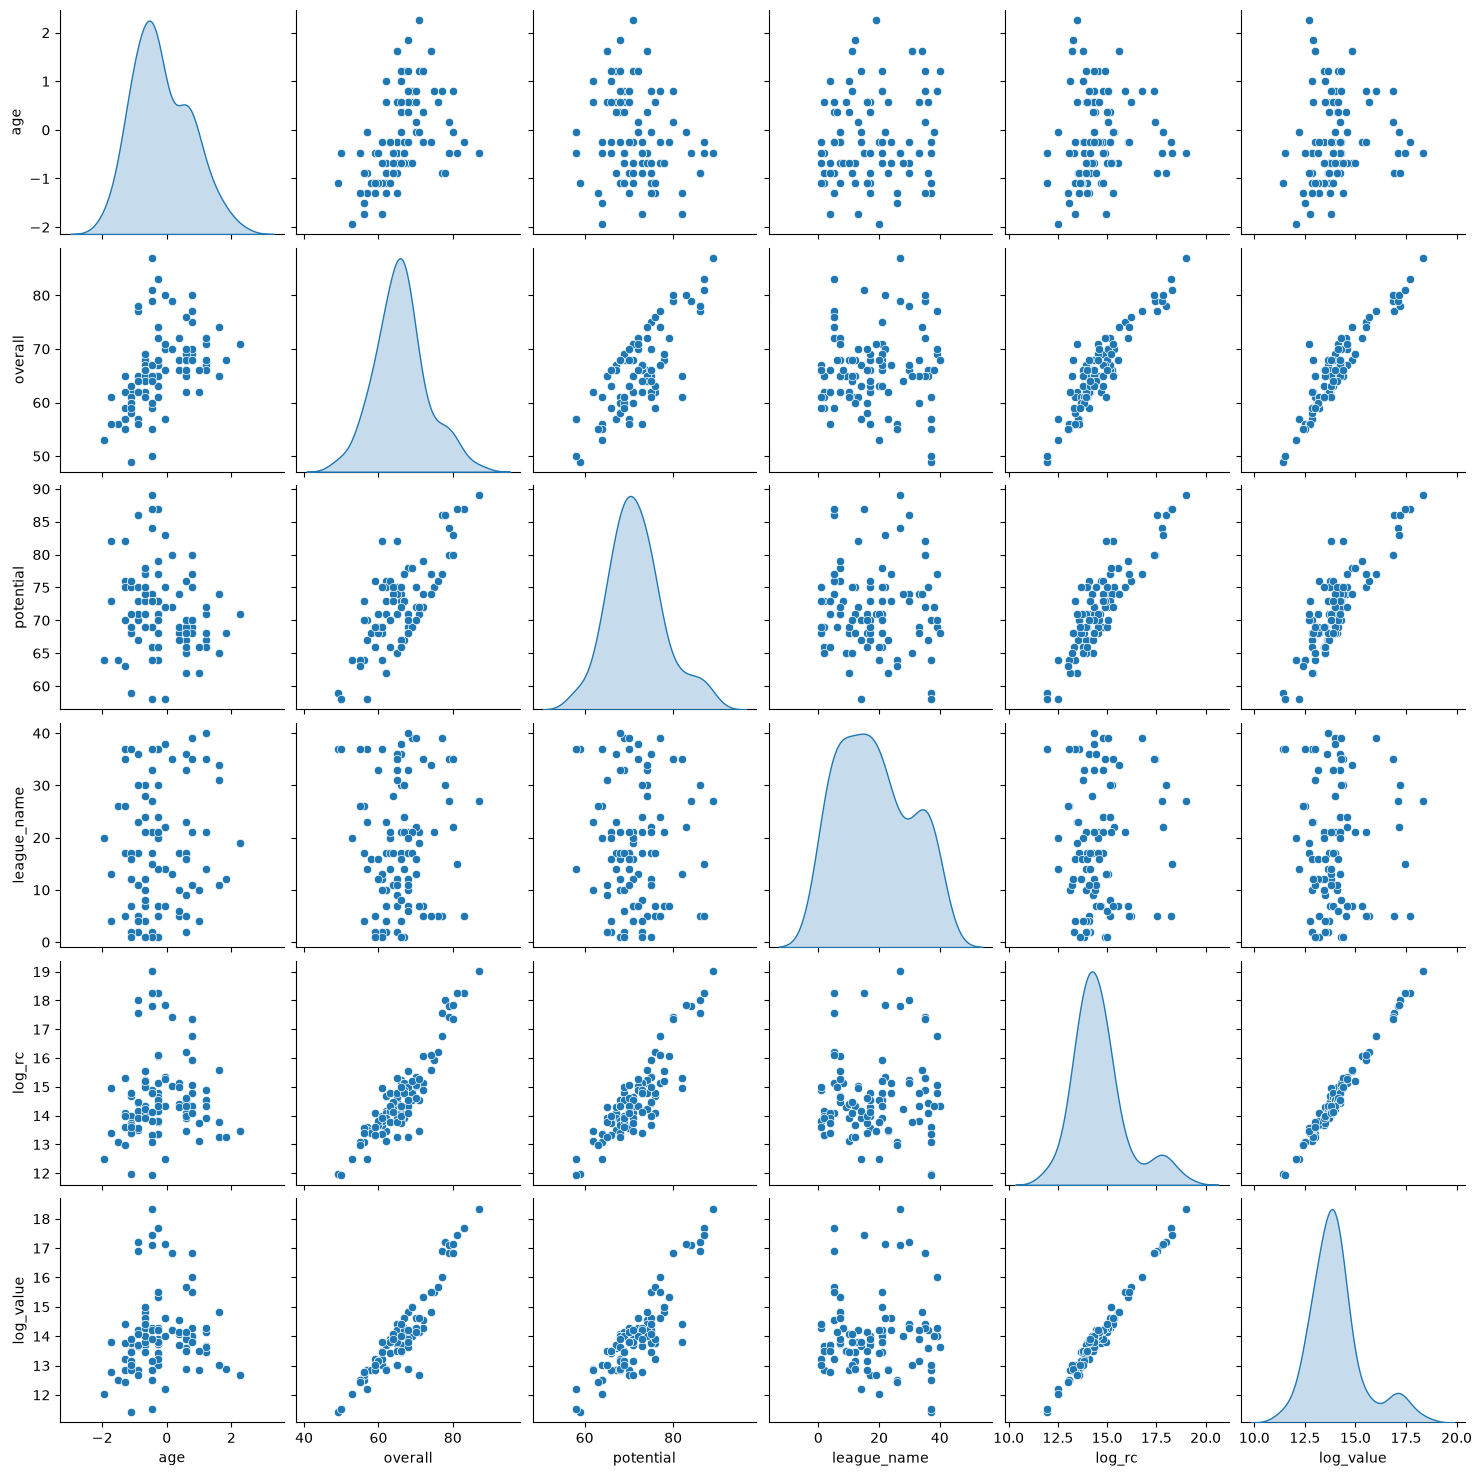

In [60]:
columns = df_final.columns
#taking random sample instead of our 18k rows
plt.figure(figsize=(16,9), dpi = 200)
sns.pairplot(df_final.sample(n=100,random_state=42), diag_kind='kde')
plt.show()

***Interpretation***

**Scatter Plots**



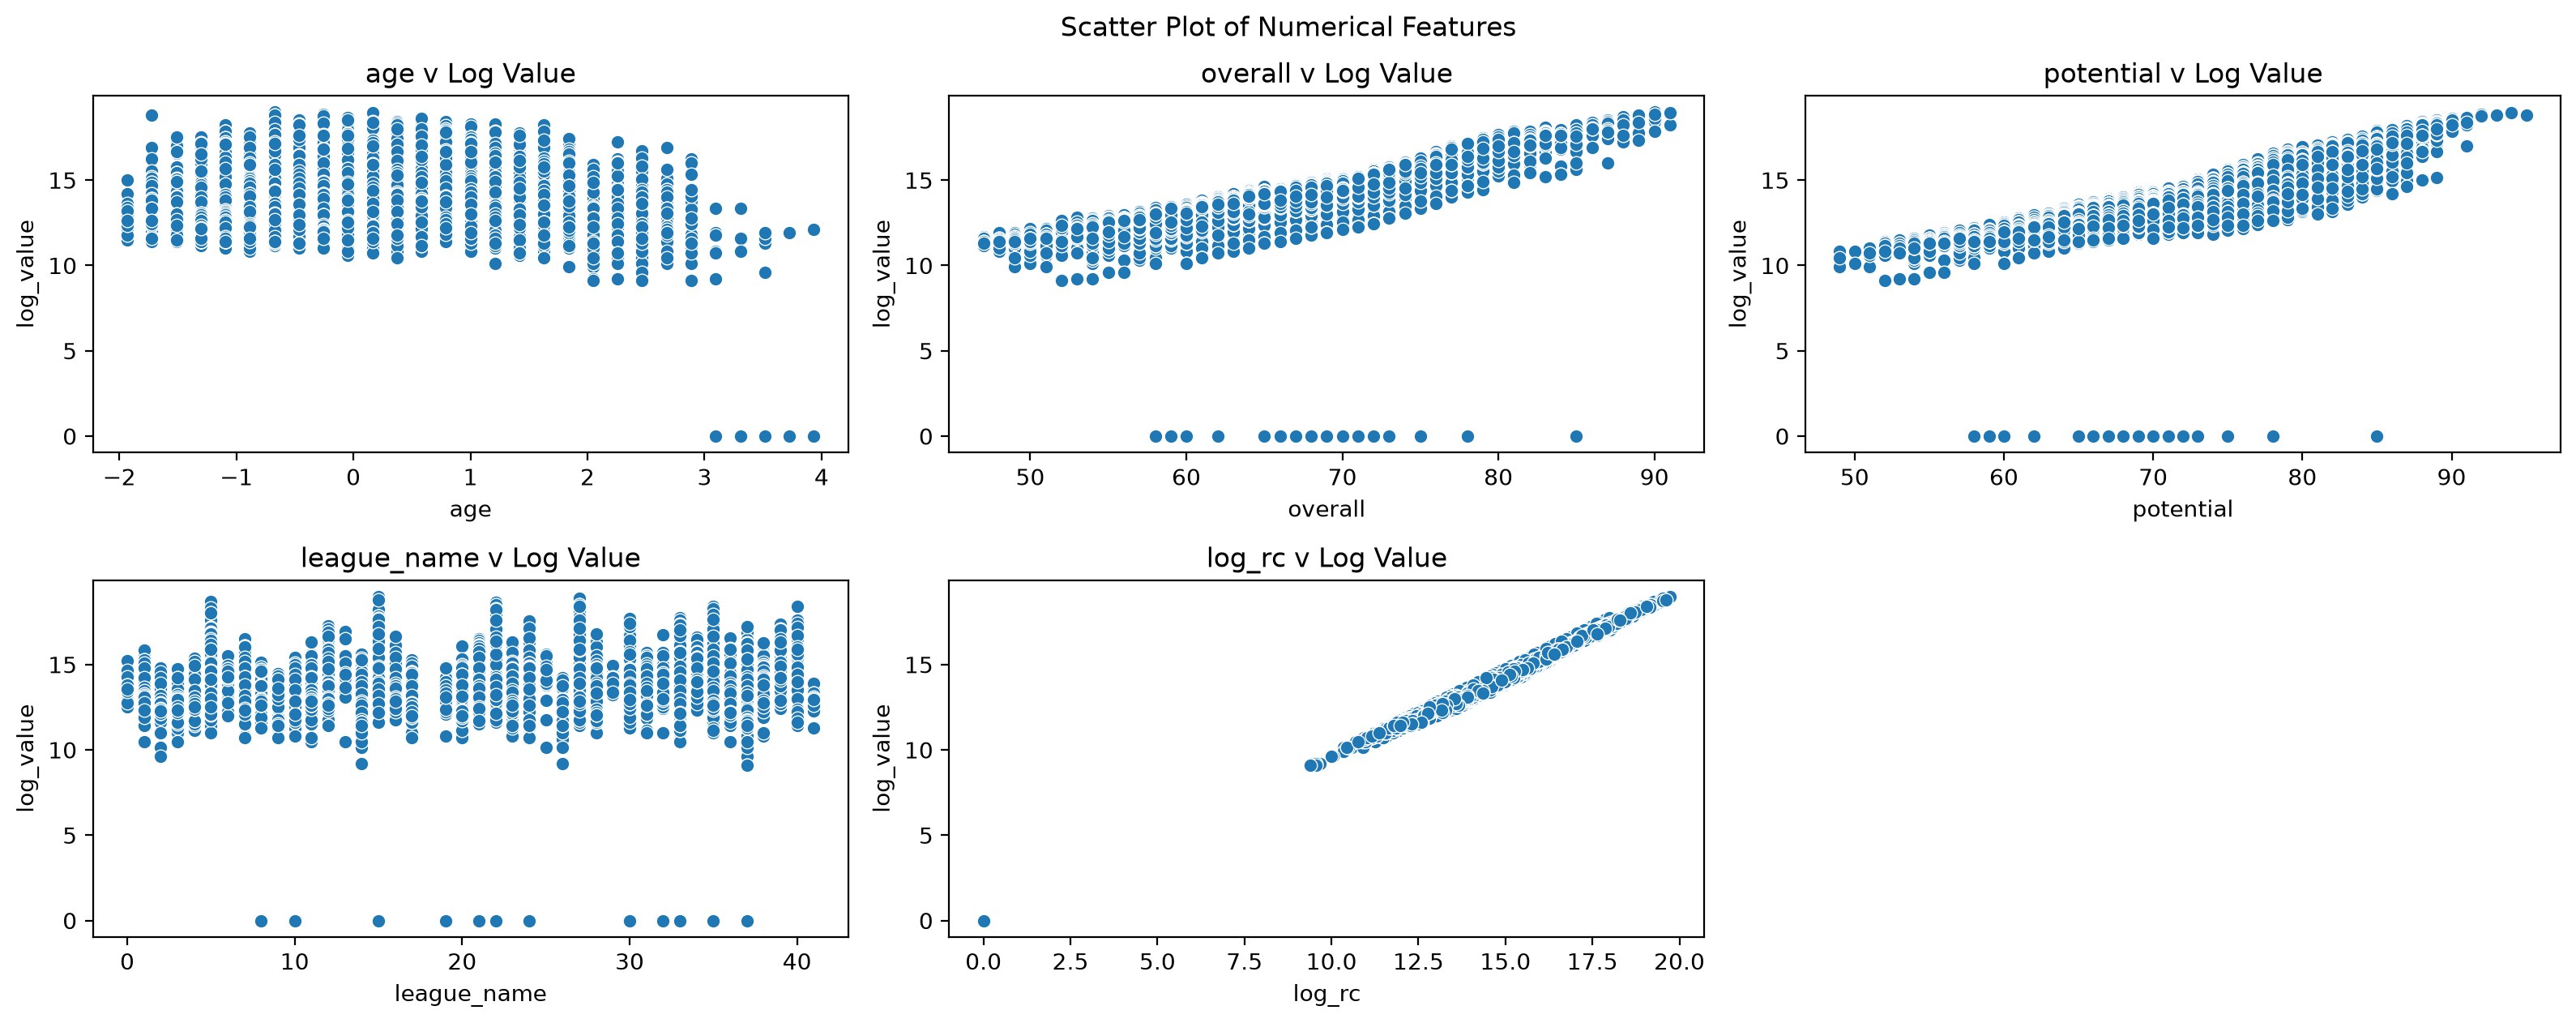

In [61]:
N = numeric_cols.shape[1] #gives no of cols

plt.figure(figsize=(16,9), dpi =200)

nr = math.ceil(N/2)
nc = math.ceil(N/2)
j = 1
for cols in numeric_cols:
    plt.subplot(nr,nc,j)
    j+=1
    sns.scatterplot(data=df_final, x = cols, y = 'log_value' )
    #plt.xlabel(cols)
    #plt.ylabel("Value")
    plt.title(f"{cols} v Log Value")


plt.suptitle("Scatter Plot of Numerical Features")
plt.tight_layout()
plt.show()


***Interpreatation***
Age shows irregular pattern because age is alone not enough
Overall and Potential have direct relation
log_rc and Log Value obv has direct relation

**Target variable distribution**

<Axes: xlabel='log_value', ylabel='Count'>

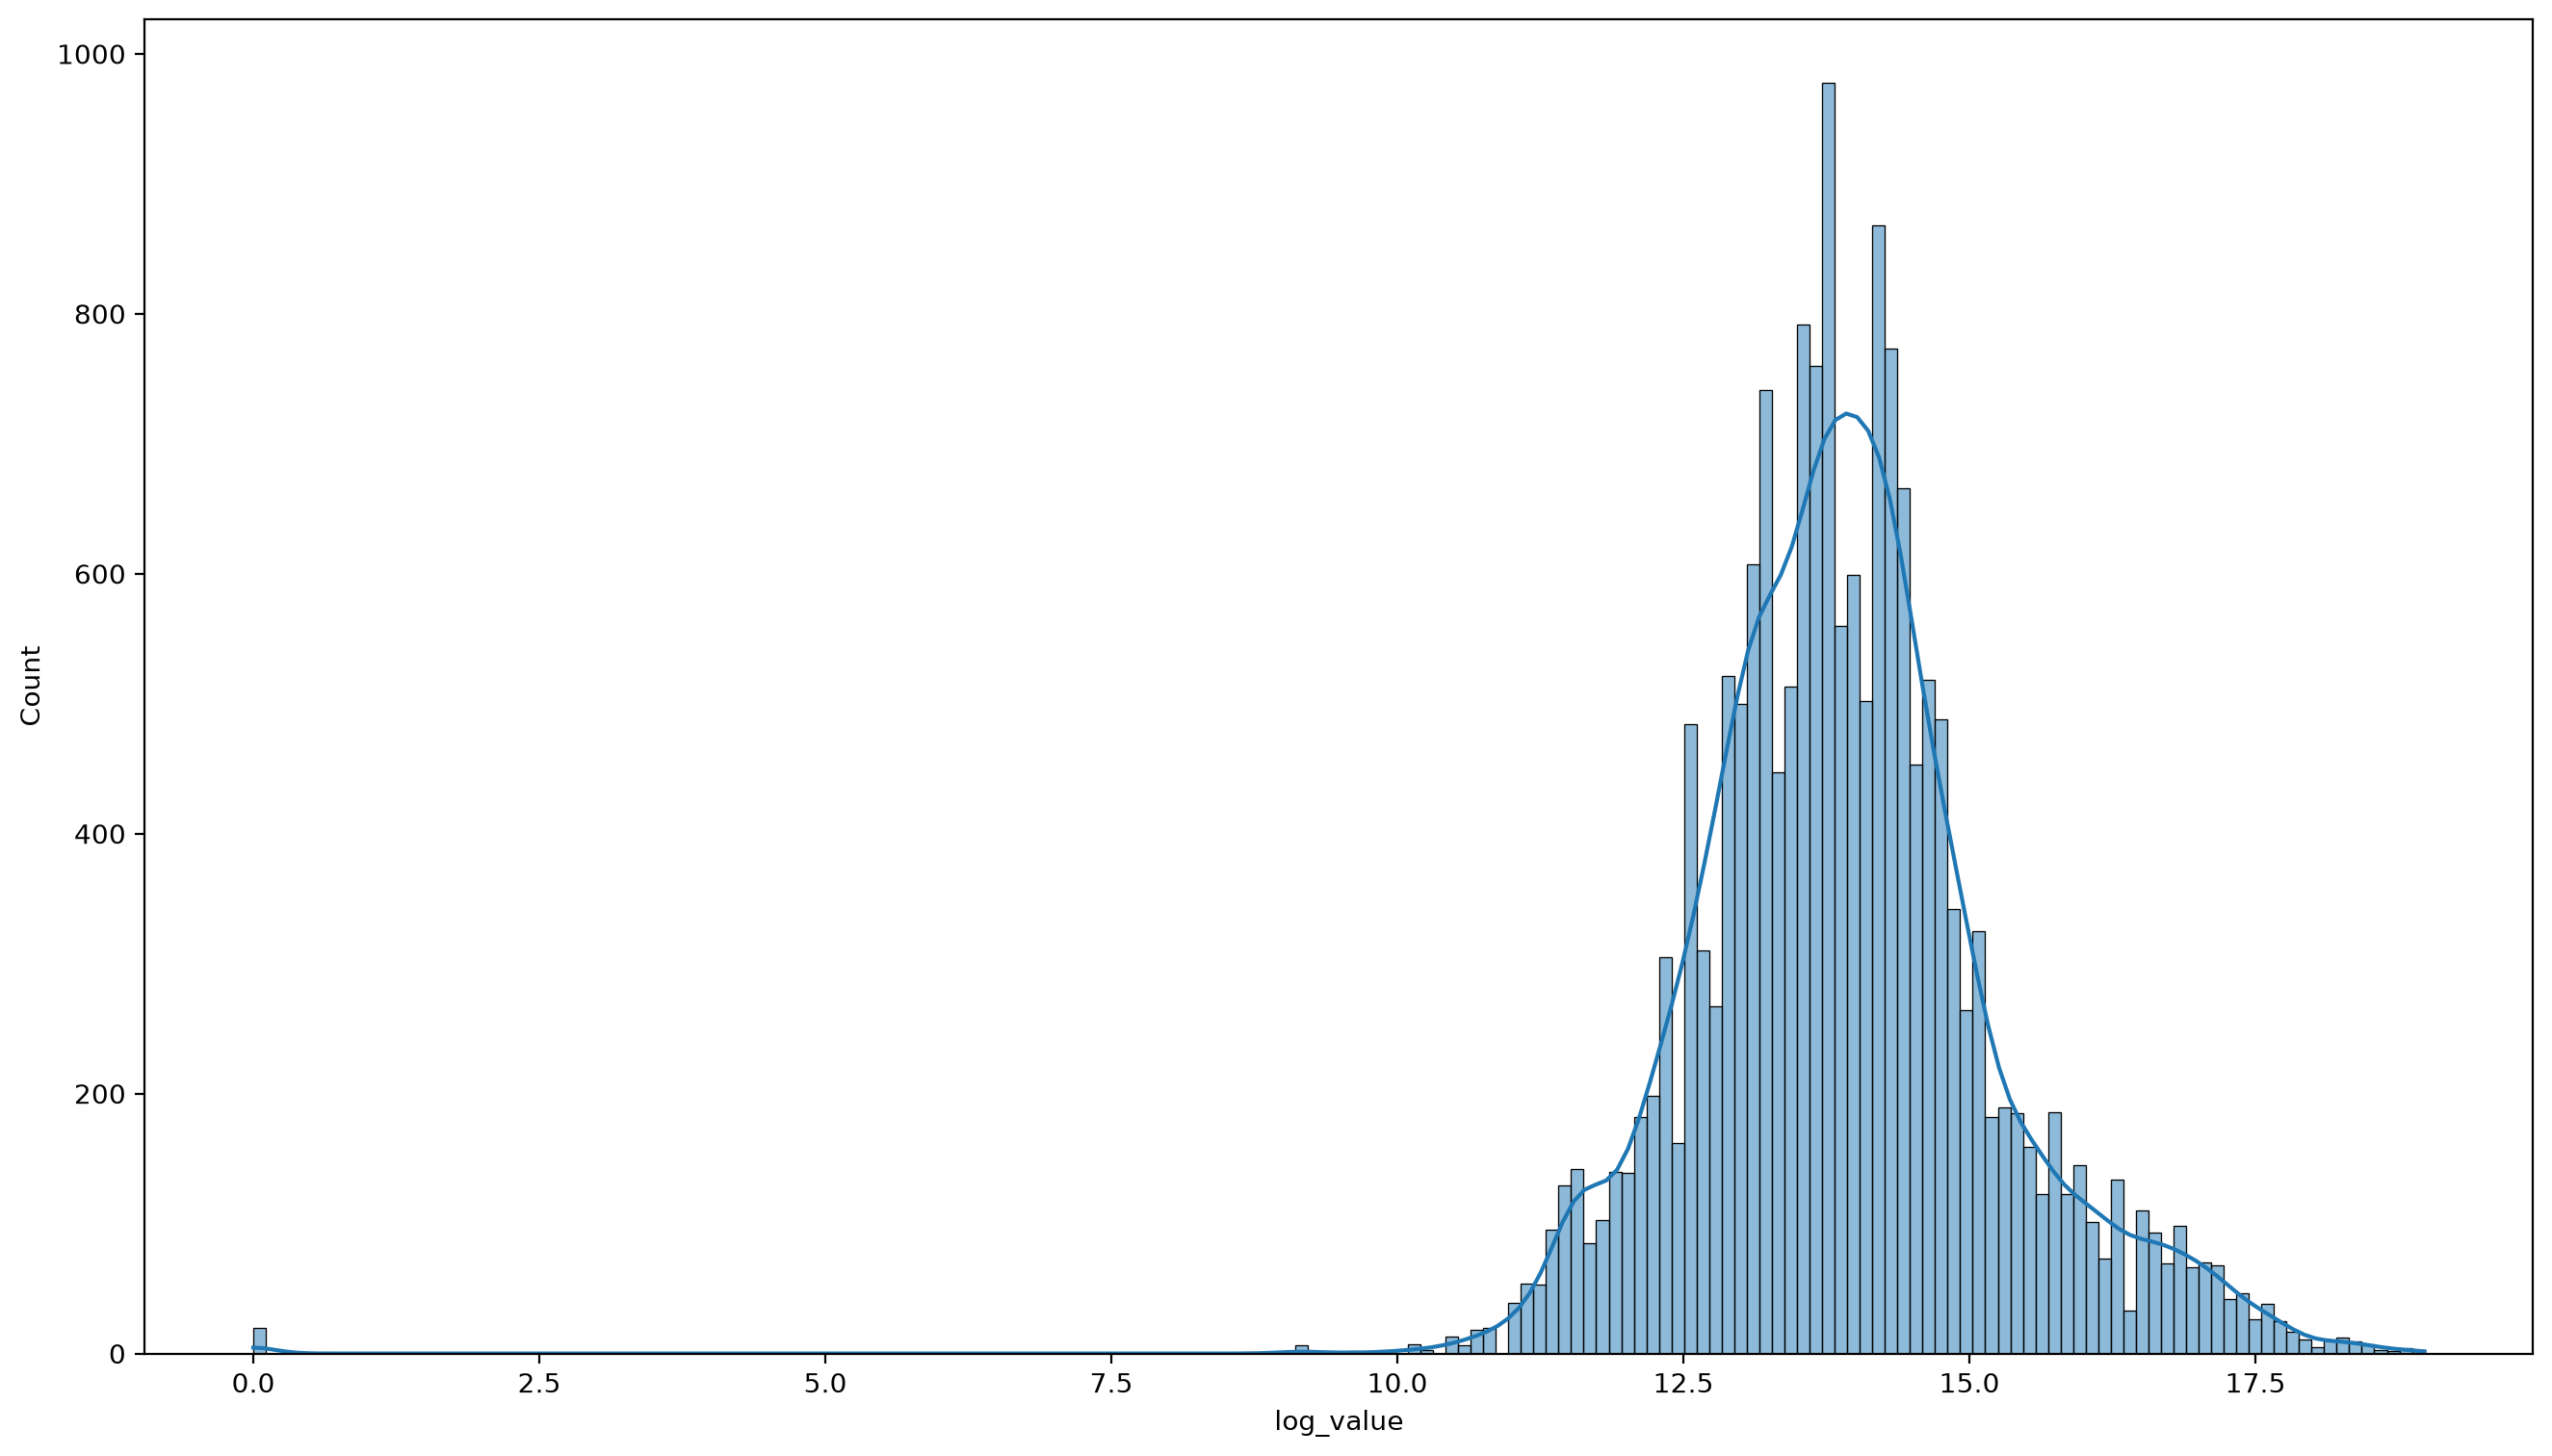

In [62]:
plt.figure(figsize=(16,9), dpi = 200)
sns.histplot(df_final["log_value"], kde =True)


***Interpretation***
Approximately normal

**Class-wise comparison plots**
Not applicable for my project as my target variable is continuous

**Feature Importance Visualization**
Not applicable rn because I have not trained the model yet, that is for next phase

***Model Training***

In [63]:
from sklearn.model_selection import train_test_split

#here I have dropped release clause as well as it can become a biased indicator
X = df_final.drop(columns = ["log_value", "log_rc"])
y = df_final["log_value"]


x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)
y_pred_lr = model.predict(x_test)

#TO CONVERT BACK TO EUROS
#y_pred_lr = np.exp(y_pred_ridge)-1

actual_values  = pd.Series(y_test, index = x_test.index,name = "Actual Value")
predicted_values = pd.Series(y_pred_lr, index = x_test.index,name ="Predicted Value")
error = predicted_values - actual_values

results = pd.concat([x_test,actual_values,predicted_values, error], axis = 1)
print(results.tail())




         age  overall  potential  league_name  Actual Value  Predicted Value  \
14455 -1.513       52         68           17        12.206           12.036   
9348  -0.047       65         68            1        13.764           13.790   
1059  -0.675       73         80            5        15.607           15.747   
14427 -1.723       58         73           23        13.071           13.407   
11503 -0.256       64         70            5        13.653           13.683   

           0  
14455 -0.170  
9348   0.026  
1059   0.139  
14427  0.336  
11503  0.030  


In [70]:
from sklearn.linear_model import Ridge
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
ridge_model = Ridge(alpha = 0.01)
ridge_model.fit(x_train_scaled,y_train)
y_pred_ridge = ridge_model.predict(x_test_scaled)

In [77]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha = 0.05)
lasso_model.fit(x_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(x_test_scaled)

In [78]:
#Evaluation Metrics
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score,precision_score,recall_score,f1_score
print("For Linear Regression Model, metrics are:")
print("R2 score is: ", r2_score(y_test,y_pred_lr))
print("Mean Absolute Error: ", mean_absolute_error(y_test,y_pred_lr))
print("Mean Score Error Score is: ", mean_squared_error(y_test,y_pred_lr))
print("Root Mean Score Error Score is: ", np.sqrt(mean_squared_error(y_test,y_pred_lr)))

#NOT DOING THESE AS ours is a continuous variable
#print("Accuracy score is: ", accuracy_score(y_test,y_pred_lr))
#print("Precision score is: ", precision_score(y_test,y_pred_lr))
#print("Recall score is: ", recall_score(y_test,y_pred_lr))
#print("F1 score is: ", f1_score(y_test,y_pred_lr))

print("\nFor Ridge Regression Model, metrics are:")
print("R2 score is: ", r2_score(y_test,y_pred_ridge))
print("Mean Absolute Error: ", mean_absolute_error(y_test,y_pred_ridge))
print("Mean Score Error Score is: ", mean_squared_error(y_test,y_pred_ridge))
print("Root Mean Score Error Score is: ", np.sqrt(mean_squared_error(y_test,y_pred_ridge)))

print("\nFor Lasso Regression Model, metrics are: ")
print("R2 score is: ", r2_score(y_test,y_pred_lasso))
print("Mean Absolute Error: ", mean_absolute_error(y_test,y_pred_lasso))
print("Mean Score Error Score is: ", mean_squared_error(y_test,y_pred_lasso))
print("Root Mean Score Error Score is: ", np.sqrt(mean_squared_error(y_test,y_pred_lasso)))

For Linear Regression Model, metrics are:
R2 score is:  0.8386418892430968
Mean Absolute Error:  0.20852032725319736
Mean Score Error Score is:  0.29613565775239603
Root Mean Score Error Score is:  0.5441834780222531

For Ridge Regression Model, metrics are:
R2 score is:  0.8386418039398543
Mean Absolute Error:  0.20851936151606235
Mean Score Error Score is:  0.2961358143068555
Root Mean Score Error Score is:  0.5441836218656856

For Lasso Regression Model, metrics are: 
R2 score is:  0.8289253470250808
Mean Absolute Error:  0.1915579826039735
Mean Score Error Score is:  0.31396813364910564
Root Mean Score Error Score is:  0.560328594352551


**Model Selection**
All models are somewhat comparable in terms of performance
The best performing models are Linear and Ridge Regression Models. I will use Linear Regression Model as it is the more commonly used model.